In [1]:
!pip install opencv-python==4.10.0.84

In [2]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import drive
from tensorflow.keras.utils import image_dataset_from_directory
import tensorflow as tf
from tensorflow.keras.models import model_from_json


In [3]:
drive.mount("/content/gdrive") # monta o drive em content

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [4]:
df = pd.read_csv('/content/gdrive/MyDrive/teste/archive/train_labels.csv')
# le o csv com os labels e suas respectivas imagens
df.shape

(12271, 2)

In [5]:
df

,image,label
0,train_00001_aligned.jpg,5
1,train_00002_aligned.jpg,5
2,train_00003_aligned.jpg,4
3,train_00004_aligned.jpg,4
4,train_00005_aligned.jpg,5
...,...,...
12266,train_12267_aligned.jpg,7
12267,train_12268_aligned.jpg,7
12268,train_12269_aligned.jpg,7
12269,train_12270_aligned.jpg,7


In [6]:

df.columns
# colunas existentes

Index(['image', 'label'], dtype='object')

In [7]:
df.head()

,image,label
0,train_00001_aligned.jpg,5
1,train_00002_aligned.jpg,5
2,train_00003_aligned.jpg,4
3,train_00004_aligned.jpg,4
4,train_00005_aligned.jpg,5


In [8]:
from PIL import Image

img = Image.open('/content/gdrive/MyDrive/teste/archive/DATASET/test/1/test_0002_aligned.jpg')
# mostra como sao as imagens va base
# tamanho: 100x100 pixels e com 3 canais de cor
print(img.size,img.mode)

(100, 100) RGB


In [9]:
data_train = image_dataset_from_directory(
    '/content/gdrive/MyDrive/teste/archive/DATASET/train',
    image_size=(64,64),
    color_mode = 'grayscale',
    batch_size=64,
    label_mode='categorical',
    shuffle=True
)
# com essa funcao de transofmração(image_dataset_from_directory) é poupado muito tempo em relaçaõ a limpeza dos dados
# pega as imagens, dda um resize para ficarem 64x64(diminuir a compelxidade)
# transforma em escala de cinza
# separa em lotes 32 por vez
# label_mode faz com que o label seja organizado como foi feito na aula(encoder), mesma coisa que utilizar o OneHotEncoder

Found 12288 files belonging to 7 classes.


In [10]:
from numpy.random import shuffle
data_test = image_dataset_from_directory(
    '/content/gdrive/MyDrive/teste/archive/DATASET/test',
    image_size = (64,64),
    color_mode='grayscale',
    batch_size=64,
    label_mode='categorical',
    shuffle=True
)

Found 3083 files belonging to 7 classes.


In [11]:
for i,x in data_train.take(1):
  # vamos verificar como ficaram as imagens apos o carregamento
  print(i.shape)
  print(x.shape)

(64, 64, 64, 1)
(64, 7)


In [12]:
def normalizar(imagem, label):
  # transformamos em escala 0-1 (os pixels), pois estava em 0-255
  img = tf.cast(imagem,tf.float32) /255.0
  return img,label

In [13]:
data_train = data_train.map(normalizar)# para cada imagem é aplicada a transformação
data_test = data_test.map(normalizar)

In [14]:
for i,x in data_train.take(1):
    print(i.numpy().min(), i.numpy().max())
    # verificando a normalização
    # pega um batch(32 imagens como definido no carregamento) e para cada imagem mostra seus pixels

0.0 1.0


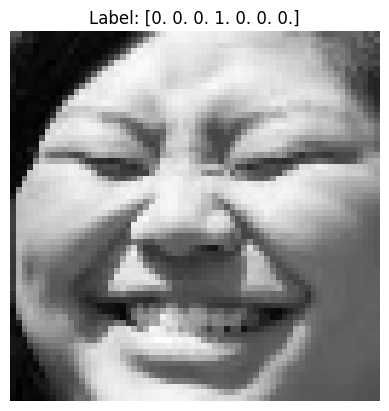

In [15]:
import matplotlib.pyplot as plt
# visualizamos a imagem apos a escala para cinza e sua normalização
for imagens, labels in data_train.take(1):
    plt.imshow(imagens[0].numpy().squeeze(), cmap='gray')
    plt.title(f'Label: {labels[0].numpy()}')
    plt.axis('off')
    plt.show()

In [16]:
# definição dos parametros que serao utilizaos na rede
feature_maps = 32
#batch_size = 64
labels_cat = 7
epochs = 100
width,height = 64,64

In [17]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,Activation,Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model
from tensorflow.keras.models import model_from_json

In [18]:
model = Sequential()
# instancia o sequential

In [19]:
total = len(data_train)  #numero de batches
val = int(total * 0.1) # 10% para validação

#os dados vindos do imagem directory vem em formato tf.data.Dataset, nao e necessario a utilização do train_test_split
# para isso uso funcoes do prorpio tensor para separar

x_val = data_train.take(val)
# pega os primeiros 10% dos batches
x_train = data_train.skip(val)  # pega o restante

# faz a sepração dos dados em dados para treino e para a validação durante o treino
# os dados de data_test serao usados para a vallidação quando o modelo estiver treinado

In [20]:
#x_train,x_val,y_train,y_val = train_test_split(x,y,test_size=0.1)


In [21]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    #tf.keras.layers.RandomZoom(0.1),
])
# faço um data aumentation para que tenha mais amostras, pois a base nao é muito grande

def aumentar(imagem, label):
    imagem = data_augmentation(imagem, training=True)
    return imagem, label

x_train = x_train.map(aumentar)

In [22]:
print(len(x_train))
print(len(x_val))
print(len(data_test))

173
19
49


In [23]:
model.add(Conv2D(feature_maps, kernel_size=(3,3),activation='relu', input_shape=(width,height,1), kernel_regularizer=l2(0.01)))
# primeira camada de convolução com 32 feature maps, kernel size 3x3, input como a imagem vai em entrar na convolução, regularizer vai penalizar maiores erros
model.add(Conv2D(feature_maps,kernel_size=(3,3), activation='relu', padding='same'))
# utiliza padding para obter o maximo possivel de carateriscas, para caso na borda falte colunas adiciona 0 para o kernel pegar as caracteristicas

model.add(BatchNormalization())
# normaluzação

model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))#diminui pela metade o feture map (32->18)
model.add(Dropout(0.2))# zera 20% dos neuronios

model.add(Conv2D(2 * feature_maps,kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
model.add(Dropout(0.2))

#model.add(Conv2D( 4 * feature_maps,kernel_size=(3,3), activation='relu', padding='same'))
#model.add(BatchNormalization())
#model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
#model.add(Dropout(0.2))

model.add(Flatten())# todos os mapas de caracteriscas(matrizes) seraio colocados em um vetor para dar entrada a rede neural

#model.add(Dense(4*feature_maps,activation='relu')) # camadas densas que vao relaizar o aprendizado da rede referente as caracteristcas retiradas
# sepraeii em duas camadas densas junto com dropout para desligar 20% dos neuronios
#model.add(Dropout(0.2))
model.add(Dense(2*feature_maps,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(labels_cat,activation='softmax'))
# camada de saida recebe 7 saidas cada uma para cada classe, a funcao softmax retorna a priobabilidade de cada classe referente ao aprendizado da rede

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 62, 62, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 31, 31, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 31, 31, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       921,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 950,567 (3.63 MB)

 Trainable params: 950,375 (3.63 MB)

 Non-trainable params: 192 (768.00 B)

In [24]:
model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
# define alguns parametros para o aprendizado da rede e metrica de validação


In [25]:
arq_modelo = 'modelo_01.h5'
arq_modelo_json = 'modelo_01_arquitetura.json'

In [26]:
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor = 0.9, patience=3, verbose = 1)
# reduz a cada 3 epochs o learning rate caso a rede nao aprender

In [27]:
early_stopper = EarlyStopping(monitor='val_loss', min_delta=0,patience=8,verbose=1,mode='auto')
# para o treino caso o val_loss nao tenha mais evolução

In [28]:
check_pointer = ModelCheckpoint(arq_modelo, monitor='val_loss', verbose =1, save_best_only=True)
# salva o melhor modelo durante as epochs e sobreescreve caso um modelo posterior seja melhor

In [29]:
model_json = model.to_json()
# salva em json a arquitetura

with open(arq_modelo_json, 'w') as json_file:
    json_file.write(model_json)

Ao realizar alguns testes, percebi que mesmo com uma acuracia decente o modelo nao estava aprendendo classes pouco vistas. Para resolver o desbalanceamneto do dataset pesquisei e implementei o class_weight que penalisa erros em determinadas classes

In [30]:
import os
#descubro o quão desbalanceado é o dataset

caminho_train = '/content/gdrive/MyDrive/teste/archive/DATASET/train'

for classe in sorted(os.listdir(caminho_train)):
    caminho_classe = os.path.join(caminho_train, classe)
    quantidade = len(os.listdir(caminho_classe))
    print(f'Classe {classe}: {quantidade} imagens')

Classe 1: 1290 imagens
Classe 2: 281 imagens
Classe 3: 717 imagens
Classe 4: 4773 imagens
Classe 5: 1982 imagens
Classe 6: 705 imagens
Classe 7: 2540 imagens


In [31]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1, 2, 3, 4, 5, 6])# classes numeradas em um array numpy
quantidades = np.array([1290, 281, 717, 4772, 1982, 705, 2524]) #pega a quantidade de imagens de cada classe

pesos = compute_class_weight(class_weight='balanced', classes=classes, y=np.repeat(classes, quantidades))
# com essa funcao ela retorna os pesos adequados para cada classe
class_weight_dict = dict(zip(classes, pesos))
# coloca tudo em um dicionario, como a funcao no fit() espera

class_weight_dict = {k: float(np.sqrt(v)) for k, v in class_weight_dict.items()}
# aplica a raiz quadrada para suavizar o peso
# em uma tentaiva anterior, sem a raiz, alguns pesos estavam muito maiores e isso afetou o treino
print(class_weight_dict)

{np.int64(0): 1.1657249798653928, np.int64(1): 2.4976857616003394, np.int64(2): 1.5636205884072178, np.int64(3): 0.6060950547754886, np.int64(4): 0.9404574106632596, np.int64(5): 1.576871847264398, np.int64(6): 0.833386157860871}


In [32]:
historico_rede = model.fit(x_train, epochs=epochs,class_weight=class_weight_dict,
                    verbose=1,validation_data=(x_val),shuffle=True,
                    callbacks=[lr_reducer,early_stopper,check_pointer])
# treino do modelo, utiliza as funcoes e parametros ja listados a cima

Epoch 1/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3116 - loss: 2.0242
Epoch 1: val_loss improved from None to 24.82115, saving model to modelo_01.h5



Epoch 1: finished saving model to modelo_01.h5
173/173 ━━━━━━━━━━━━━━━━━━━━ 909s 5s/step - accuracy: 0.3438 - loss: 1.7878 - val_accuracy: 0.0485 - val_loss: 24.8211 - learning_rate: 0.0010
Epoch 2/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.3726 - loss: 1.6739
Epoch 2: val_loss improved from 24.82115 to 15.01794, saving model to modelo_01.h5



Epoch 2: finished saving model to modelo_01.h5
173/173 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step - accuracy: 0.3791 - loss: 1.6635 - val_accuracy: 0.0814 - val_loss: 15.0179 - learning_rate: 0.0010
Epoch 3/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.4095 - loss: 1.6199
Epoch 3: val_loss improved from 15.01794 to 1.63623, saving model to modelo_01.h5



Epoch 3: finished saving model to modelo_01.h5
173/173 ━━━━━━━━━━━━━━━━━━━━ 20s 108ms/step - accuracy: 0.4086 - loss: 1.6307 - val_accuracy: 0.4367 - val_loss: 1.6362 - learning_rate: 0.0010
Epoch 4/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4161 - loss: 1.5949
Epoch 4: val_loss improved from 1.63623 to 1.56895, saving model to modelo_01.h5



Epoch 4: finished saving model to modelo_01.h5
173/173 ━━━━━━━━━━━━━━━━━━━━ 267s 2s/step - accuracy: 0.4105 - loss: 1.6004 - val_accuracy: 0.4243 - val_loss: 1.5689 - learning_rate: 0.0010
Epoch 5/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.4304 - loss: 1.5778
Epoch 5: val_loss did not improve from 1.56895
173/173 ━━━━━━━━━━━━━━━━━━━━ 20s 104ms/step - accuracy: 0.4291 - loss: 1.5809 - val_accuracy: 0.4079 - val_loss: 1.8132 - learning_rate: 0.0010
Epoch 6/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.4455 - loss: 1.5556
Epoch 6: val_loss improved from 1.56895 to 1.35767, saving model to modelo_01.h5


...


Epoch 28: finished saving model to modelo_01.h5
173/173 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - accuracy: 0.5858 - loss: 1.1702 - val_accuracy: 0.6933 - val_loss: 0.9034 - learning_rate: 7.2900e-04
Epoch 29/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.5859 - loss: 1.1668
Epoch 29: val_loss did not improve from 0.90339
173/173 ━━━━━━━━━━━━━━━━━━━━ 25s 102ms/step - accuracy: 0.5844 - loss: 1.1670 - val_accuracy: 0.6711 - val_loss: 0.9624 - learning_rate: 7.2900e-04
Epoch 30/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5899 - loss: 1.1543
Epoch 30: val_loss did not improve from 0.90339
173/173 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - accuracy: 0.5863 - loss: 1.1554 - val_accuracy: 0.7007 - val_loss: 0.9070 - learning_rate: 7.2900e-04
Epoch 31/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.5824 - loss: 1.1665
Epoch 31: ReduceLROnPlateau reducing learning rate to 0.0006561000715009868.

Epoch 31: val_loss did not improve from 0.90339
173/173 ━━━━━━━━━━


Epoch 36: finished saving model to modelo_01.h5
173/173 ━━━━━━━━━━━━━━━━━━━━ 19s 102ms/step - accuracy: 0.6047 - loss: 1.1191 - val_accuracy: 0.6957 - val_loss: 0.9003 - learning_rate: 5.9049e-04
Epoch 37/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.5994 - loss: 1.1279
Epoch 37: val_loss improved from 0.90032 to 0.88761, saving model to modelo_01.h5



Epoch 37: finished saving model to modelo_01.h5
173/173 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - accuracy: 0.6031 - loss: 1.1143 - val_accuracy: 0.7179 - val_loss: 0.8876 - learning_rate: 5.9049e-04
Epoch 38/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.6038 - loss: 1.1187
Epoch 38: val_loss did not improve from 0.88761
173/173 ━━━━━━━━━━━━━━━━━━━━ 20s 104ms/step - accuracy: 0.6024 - loss: 1.1185 - val_accuracy: 0.6809 - val_loss: 0.9930 - learning_rate: 5.9049e-04
Epoch 39/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.6082 - loss: 1.0985
Epoch 39: val_loss did not improve from 0.88761
173/173 ━━━━━━━━━━━━━━━━━━━━ 19s 103ms/step - accuracy: 0.6015 - loss: 1.1132 - val_accuracy: 0.6801 - val_loss: 0.9674 - learning_rate: 5.9049e-04
Epoch 40/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.5985 - loss: 1.1048
Epoch 40: val_loss improved from 0.88761 to 0.85723, saving model to modelo_01.h5



Epoch 40: finished saving model to modelo_01.h5
173/173 ━━━━━━━━━━━━━━━━━━━━ 20s 108ms/step - accuracy: 0.6012 - loss: 1.1070 - val_accuracy: 0.7064 - val_loss: 0.8572 - learning_rate: 5.9049e-04
Epoch 41/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.6037 - loss: 1.1161
Epoch 41: val_loss improved from 0.85723 to 0.84308, saving model to modelo_01.h5



Epoch 41: finished saving model to modelo_01.h5
173/173 ━━━━━━━━━━━━━━━━━━━━ 19s 102ms/step - accuracy: 0.6040 - loss: 1.1079 - val_accuracy: 0.7023 - val_loss: 0.8431 - learning_rate: 5.9049e-04
Epoch 42/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.6074 - loss: 1.1211
Epoch 42: val_loss did not improve from 0.84308
173/173 ━━━━━━━━━━━━━━━━━━━━ 19s 102ms/step - accuracy: 0.6076 - loss: 1.1103 - val_accuracy: 0.7204 - val_loss: 0.8650 - learning_rate: 5.9049e-04
Epoch 43/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.6120 - loss: 1.1025
Epoch 43: val_loss did not improve from 0.84308
173/173 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - accuracy: 0.6131 - loss: 1.0987 - val_accuracy: 0.7072 - val_loss: 0.8693 - learning_rate: 5.9049e-04
Epoch 44/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.6100 - loss: 1.0944
Epoch 44: ReduceLROnPlateau reducing learning rate to 0.0005314410547725857.

Epoch 44: val_loss did not improve from 0.84308
173/173 ━━━━━━━━━━

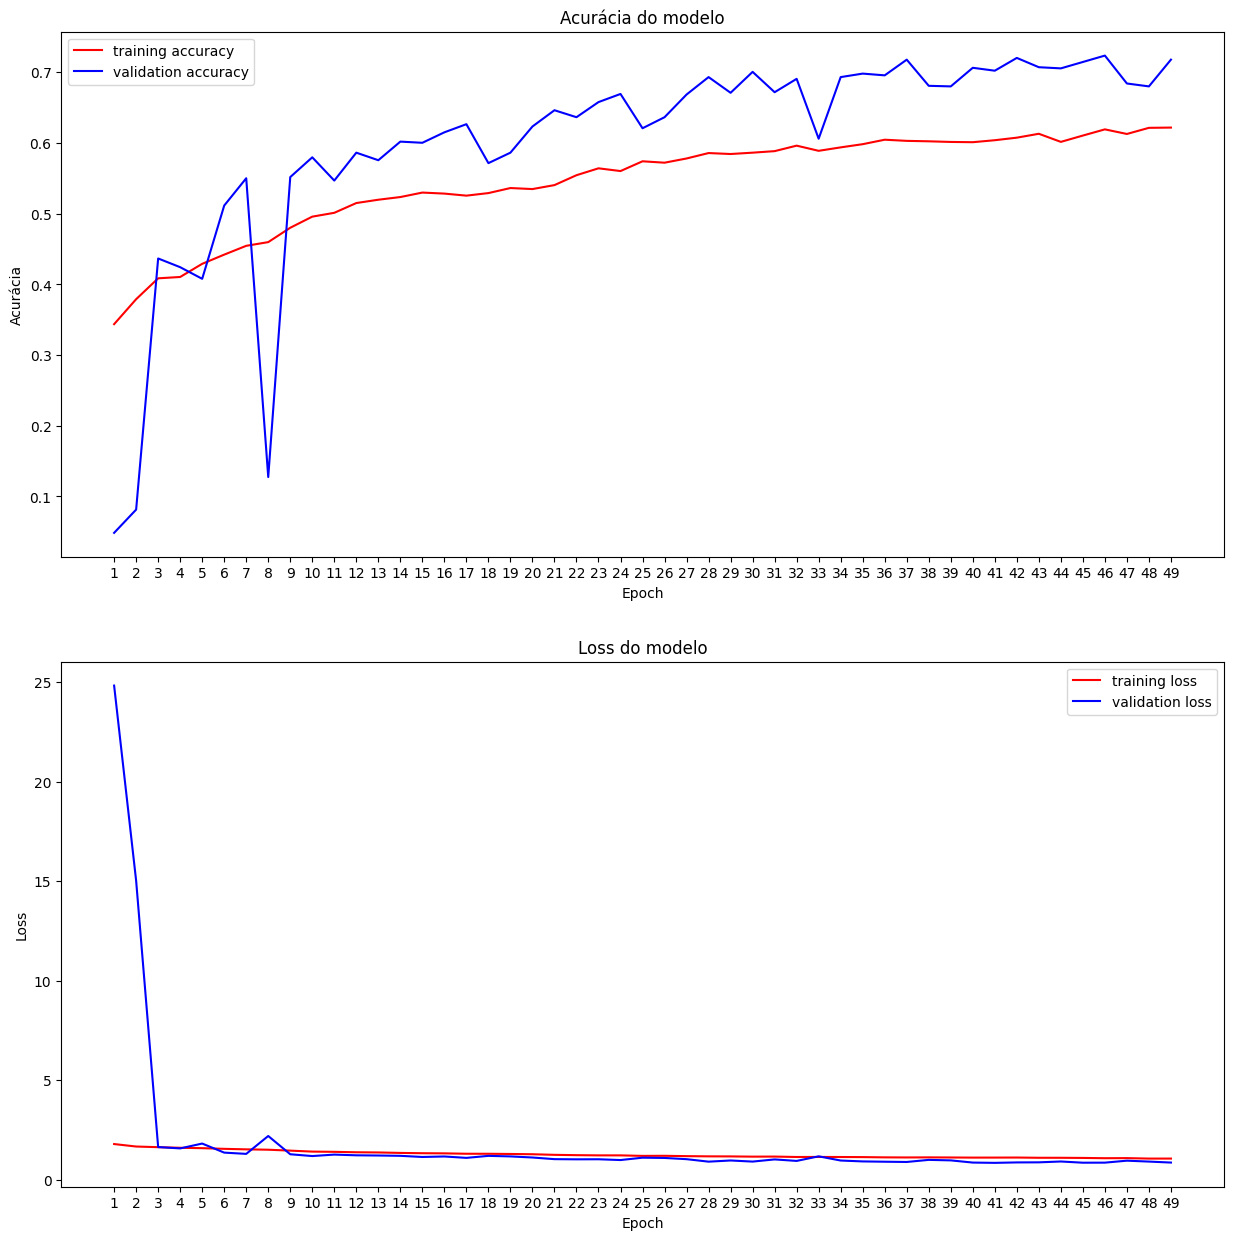

In [33]:
# mostra como foi o modelo no treino e nos testes de validação
# copiei do arquivo de aula pois achei necessario os graficos para interpretar
def plota_historico_modelo(historico_modelo):
    fig, axs = plt.subplots(2, 1, figsize=(15,15))
    axs[0].plot(range(1, len(historico_modelo.history['accuracy']) + 1), historico_modelo.history['accuracy'], 'r')
    axs[0].plot(range(1, len(historico_modelo.history['val_accuracy']) + 1), historico_modelo.history['val_accuracy'], 'b')
    axs[0].set_title('Acurácia do modelo')
    axs[0].set_ylabel('Acurácia')
    axs[0].set_xlabel('Epoch')
    axs[0].set_xticks(np.arange(1, len(historico_modelo.history['accuracy']) + 1))
    axs[0].legend(['training accuracy', 'validation accuracy'], loc = 'best')

    axs[1].plot(range(1, len(historico_modelo.history['loss']) + 1), historico_modelo.history['loss'], 'r')
    axs[1].plot(range(1, len(historico_modelo.history['val_loss']) + 1), historico_modelo.history['val_loss'], 'b')
    axs[1].set_title('Loss do modelo')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].set_xticks(np.arange(1, len(historico_modelo.history['loss']) + 1))
    axs[1].legend(['training loss', 'validation loss'], loc = 'best')
    fig.savefig('historico_modelo_mod01.png')

plota_historico_modelo(historico_rede)

In [34]:
modelo_carregado = load_model('modelo_01.h5')
# pega o melhor modelo durante o treino, check_pointer

In [35]:
validacao_testes = modelo_carregado.evaluate(data_test)
# verificamos como o modelo vai com imagens que nunca viu

49/49 ━━━━━━━━━━━━━━━━━━━━ 592s 12s/step - accuracy: 0.6922 - loss: 0.8932


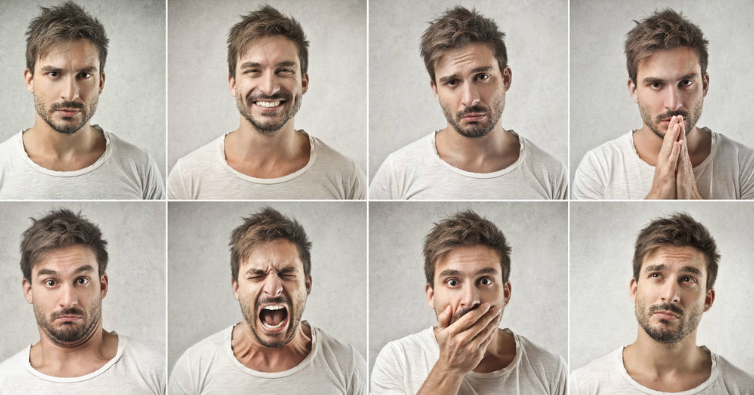

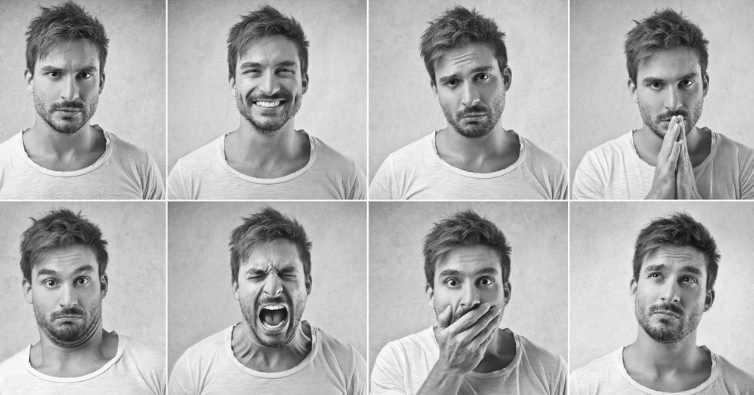

In [37]:
imagem = cv2.imread('/content/gdrive/MyDrive/teste/Material/Material/testes/teste02.jpg')
# le uma imagem de teste
cv2_imshow(imagem)

original = imagem.copy()
gray = cv2.cvtColor(original,cv2.COLOR_BGR2GRAY)
# transforma a imagem em cinza
cv2_imshow(gray)

In [38]:
model_json = model.to_json()
with open('modelo_raf_db.json', 'w') as json_file:
    json_file.write(model_json)

# salva os pesos
model.save_weights('modelo_raf_db_02.weights.h5')

In [39]:
#json_file = open('modelo_raf_db.json', 'r')
#loaded_model_json = json_file.read()
# carrega a arquitetura da rede salvo em json
#json_file.close()

In [40]:
#loaded_model = model_from_json(loaded_model_json)
#loaded_model.load_weights('modelo_raf_db.weights.h5')

In [42]:
face_cascade = cv2.CascadeClassifier('/content/gdrive/MyDrive/teste/Material/Material/haarcascade_frontalface_default.xml')
face = face_cascade.detectMultiScale(gray,1.1,3)

In [43]:
expressoes = ['Surpresa', 'Medo', 'Nojo', 'Feliz', 'Triste', 'Raiva', 'Neutro']
#lista com as expressoes

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 863ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


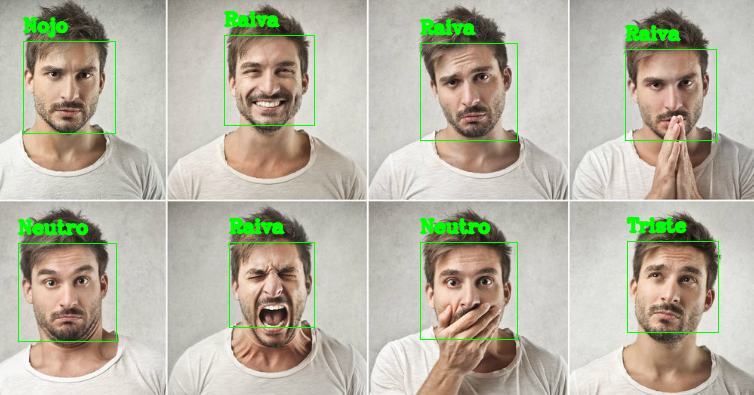

In [44]:
for (x,y,w,h) in face: # coloca a previsao em cima da caixa que indica o ROI da face
  cv2.rectangle(original, (x,y), (x+w, y+h), (0, 255,0), 1)
  roi_gray = gray[y:y+h, x:x + w]
  roi_gray = roi_gray.astype('float') / 255.0
  cropped_img = np.expand_dims(np.expand_dims(cv2.resize(roi_gray, (64,64)), -1), 0)
  prediction = model.predict(cropped_img)[0]
  cv2.putText(original,expressoes[int(np.argmax(prediction))], (x,y - 10), cv2.FONT_HERSHEY_COMPLEX, 0.6,(0,255,0),2, cv2.LINE_AA)

cv2_imshow(original)